# Concept Tutorial: Plotting

> **Note**
>
> This is still very incomplete
>
> Paul

Because plotting will often involve plotting columns from data, the `smf.plot` module provides a set of wrappers for matplotlib.

Unlike in the original FRETBursts, these are designed to be thin wrappers,
in general, if a keyword argument is not passed by the user, the underlying matplotlib function receives no additional keyword argumnet.

First let's import some data to plot, and then we'll see how plotting works.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import fretbursts as smf

# load raw data
raw = smf.photonHDF5.load('HP3_TE300_SPC630.hdf5')
data = smf.photonHDF5.regularize_dets(raw)

bg = smf.fretfactory.make_bg(data, func=smf.bg.exp_mlefit, tail_min=5e-4, auto_threshold=True)
bs = smf.fretfactory.make_burst_search(bg=bg['bg'], m=10, F=6.0, streams=(smf.PhSel('0ex'), smf.PhSel('1ex1em')))
gFret = smf.make_geq_gate(bs['NphDex_bg'], 40) & smf.make_geq_gate(bs['NphAA_bg'], 20)

--------------------------------------------------------------
 You are running FRETBursts (version 1.0.1).

 If you use this software please cite the following paper:

   FRETBursts: An Open Source Toolkit for Analysis of Freely-Diffusing Single-Molecule FRET
   Ingargiola et al. (2016). http://dx.doi.org/10.1371/journal.pone.0160716 

--------------------------------------------------------------


## Histogram Plotting

The functions for plotting histograms are:
1. `smf.plot.hist_bar()` uses [ax.bar](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.bar.html)
2. `smf.plot.hist_stair()` uses [ax.stairs](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.stairs.html)
3. `smf.plot.hist_line()` uses [ax.plot](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.plot.html)


(array([ 20,  44,  64,  95, 133, 145, 190, 182, 154, 155, 125, 105,  87,
         85,  66,  54,  45,  51,  43,  53,  49,  45,  33,  28,  31,  32,
         39,  31,  27,  26,  30,  29,  27,  27,  24,  17,  16,  14,  15,
         13,   9,   6,  10,  10,   1,   1,   1,   0,   0,   0]),
 array([0.  , 0.02, 0.04, 0.06, 0.08, 0.1 , 0.12, 0.14, 0.16, 0.18, 0.2 ,
        0.22, 0.24, 0.26, 0.28, 0.3 , 0.32, 0.34, 0.36, 0.38, 0.4 , 0.42,
        0.44, 0.46, 0.48, 0.5 , 0.52, 0.54, 0.56, 0.58, 0.6 , 0.62, 0.64,
        0.66, 0.68, 0.7 , 0.72, 0.74, 0.76, 0.78, 0.8 , 0.82, 0.84, 0.86,
        0.88, 0.9 , 0.92, 0.94, 0.96, 0.98, 1.  ]),
 <BarContainer object of 50 artists>,
 Text(0.5, 0, '$^{ii}E_{app}$'),
 Text(0, 0.5, '# Bursts'))

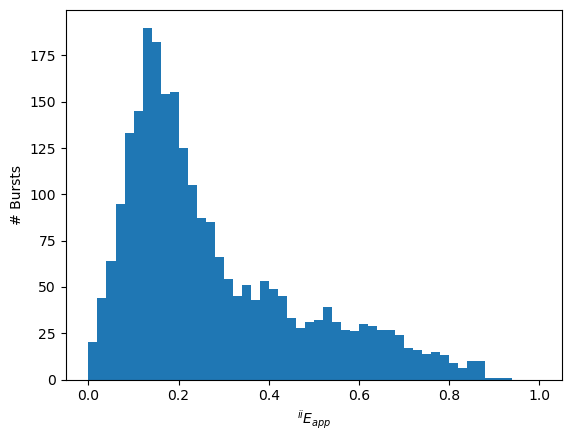

In [2]:
smf.plot.hist_bar(data, bs['E_bg'], bins=np.linspace(0,1,51), gate=gFret)